# Skenario 3: Pengaruh Panjang Teks terhadap Deteksi Inkonsistensi

**Pertanyaan Penelitian:** Apakah panjang teks review berpengaruh signifikan terhadap kemampuan model mendeteksi inkonsistensi? Di segmen mana model paling dan paling tidak akurat?

Dataset disegmentasi menjadi tiga kelompok, lalu dievaluasi menggunakan model terbaik dari Skenario 2 (IndoBERT Variant C):

| Segmen | Rentang | Karakteristik |
|--------|---------|---------------|
| Pendek | < 20 kata | Sinyal linguistik sedikit — "Bagus, recommended" |
| Sedang | 20 - 50 kata | Sinyal cukup, satu aspek dominan |
| Panjang | > 50 kata | Multi-aspek, sentimen campuran |

## 1. Setup dan Instalasi

In [1]:
import subprocess, sys

packages = [
    'torch', 'transformers', 'scikit-learn',
    'pandas', 'numpy', 'tqdm', 'matplotlib', 'seaborn'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Semua library berhasil diinstall.')

Installing torch...
Installing transformers...
Installing scikit-learn...
Installing pandas...
Installing numpy...
Installing tqdm...
Installing matplotlib...
Installing seaborn...
Semua library berhasil diinstall.


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, random

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


## 2. Load dan Persiapan Data

In [3]:
df = pd.read_csv('clean_reviews.csv')
print(f'Total data: {len(df):,}')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi label:')
print(df['label'].value_counts())
print(f'\nPersentase inkonsisten: {df["label"].mean()*100:.2f}%')
df.head(3)

Total data: 81,843
Kolom: ['app', 'app_id', 'username', 'rating', 'text', 'text_original', 'thumbs_up', 'date', 'reply', 'lang', 'word_count', 'text_sentiment', 'sentiment_confidence', 'label']

Distribusi label:
label
0.0    74801
1.0     7041
Name: count, dtype: int64

Persentase inkonsisten: 8.60%


,app,app_id,username,rating,text,text_original,thumbs_up,date,reply,lang,word_count,text_sentiment,sentiment_confidence,label
0,Gojek,com.gojek.app,Pengguna Google,3,"sorry not sorry, driver yg ga mau jemput saya ...","Sorry not sorry, driver yg ga mau jemput saya ...",0.0,2026-06-07 09:50:27,"Hai Kak Rose, mohon maaf atas ketidaknyamanann...",id,15.0,NEGATIVE,1.0,0.0
1,Gojek,com.gojek.app,Pengguna Google,4,sengaja pesen yang goride comfort biar datengn...,sengaja pesen yang goride comfort biar datengn...,0.0,2026-06-07 08:49:52,NaN,id,16.0,NEGATIVE,1.0,1.0
2,Gojek,com.gojek.app,Pengguna Google,5,"aplikasi yg sangat membantu,tidak ribet,mudah ...","aplikasi yg sangat membantu,tidak ribet,mudah ...",0.0,2026-06-07 08:45:18,NaN,id,7.0,POSITIVE,1.0,0.0


### 2.1 Segmentasi Berdasarkan Panjang Teks

In [4]:
if 'word_count' not in df.columns:
    df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

def assign_segment(wc):
    if wc < 20:   return 'Pendek'
    if wc <= 50:  return 'Sedang'
    return 'Panjang'

df['segment'] = df['word_count'].apply(assign_segment)
SEGMENT_ORDER = ['Pendek', 'Sedang', 'Panjang']

print('Distribusi segmen teks:')
seg_counts = df['segment'].value_counts().reindex(SEGMENT_ORDER)
for seg, cnt in seg_counts.items():
    print(f'  {seg:<8}: {cnt:,} review ({cnt/len(df)*100:.1f}%)')

print('\nStatistik word_count per segmen:')
display(
    df.groupby('segment')['word_count']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .round(2)
      .reindex(SEGMENT_ORDER)
)

Distribusi segmen teks:
  Pendek  : 52,876 review (64.6%)
  Sedang  : 23,188 review (28.3%)
  Panjang : 5,779 review (7.1%)

Statistik word_count per segmen:


,count,mean,median,min,max
segment,,,,,
Pendek,52876,10.20,9.0,3.0,19.0
Sedang,23188,30.43,29.0,20.0,50.0
Panjang,5778,66.29,65.0,51.0,101.0


### 2.2 Distribusi Label per Segmen

In [5]:
print('Distribusi label per segmen:')
seg_label = df.groupby('segment')['label'].agg(
    Total='count',
    Inkonsisten='sum'
).assign(Konsisten=lambda x: x['Total'] - x['Inkonsisten'])
seg_label['Pct_Inkonsisten (%)'] = (seg_label['Inkonsisten'] / seg_label['Total'] * 100).round(2)
display(seg_label.reindex(SEGMENT_ORDER))

Distribusi label per segmen:


,Total,Inkonsisten,Konsisten,Pct_Inkonsisten (%)
segment,,,,
Pendek,52876,4202.0,48674.0,7.95
Sedang,23188,2298.0,20890.0,9.91
Panjang,5778,541.0,5237.0,9.36


### 2.3 Balancing Dataset dan Split

In [6]:
df_incon = df[df['label'] == 1]
df_con   = df[df['label'] == 0].sample(
    n=min(len(df_incon) * 3, len(df[df['label'] == 0])), random_state=SEED
)

df_balanced = pd.concat([df_incon, df_con]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Dataset balanced: {len(df_balanced):,}')
print(df_balanced['label'].value_counts())
print('\nDistribusi segmen di dataset balanced:')
print(df_balanced['segment'].value_counts().reindex(SEGMENT_ORDER))

train_df, temp_df = train_test_split(
    df_balanced, test_size=0.3, random_state=SEED, stratify=df_balanced['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label']
)

print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('\nDistribusi segmen di test set:')
print(test_df['segment'].value_counts().reindex(SEGMENT_ORDER))

Dataset balanced: 28,164
label
0.0    21123
1.0     7041
Name: count, dtype: int64

Distribusi segmen di dataset balanced:
segment
Pendek     17949
Sedang      8228
Panjang     1987
Name: count, dtype: int64

Train: 19,714 | Val: 4,225 | Test: 4,225

Distribusi segmen di test set:
segment
Pendek     2680
Sedang     1241
Panjang     304
Name: count, dtype: int64


## 3. Eksplorasi Data Segmen

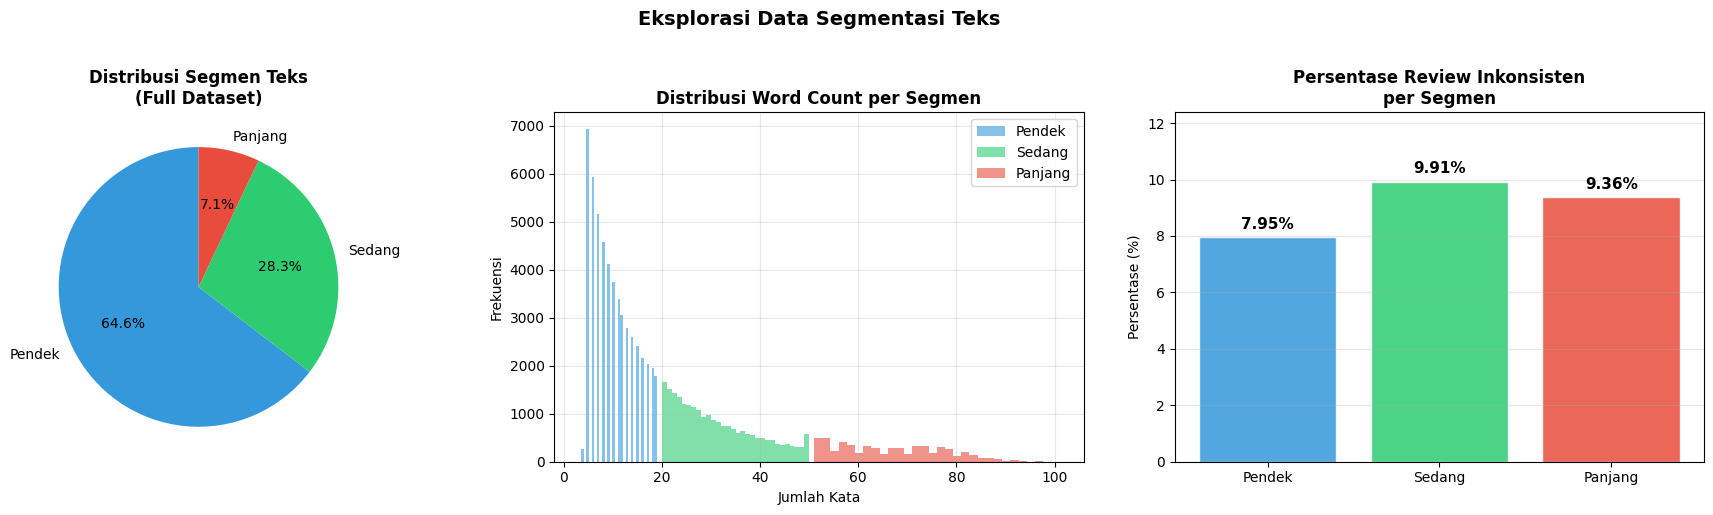

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors    = ['#3498db', '#2ecc71', '#e74c3c']

ax = axes[0]
seg_cnt = df['segment'].value_counts().reindex(SEGMENT_ORDER)
ax.pie(seg_cnt, labels=SEGMENT_ORDER, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Distribusi Segmen Teks\n(Full Dataset)', fontsize=12, fontweight='bold')

ax = axes[1]
for seg, color in zip(SEGMENT_ORDER, colors):
    ax.hist(df[df['segment'] == seg]['word_count'], bins=30, alpha=0.6, label=seg, color=color)
ax.set_title('Distribusi Word Count per Segmen', fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah Kata'); ax.set_ylabel('Frekuensi')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
pct_vals = [df[df['segment'] == seg]['label'].mean() * 100 for seg in SEGMENT_ORDER]
bars = ax.bar(SEGMENT_ORDER, pct_vals, color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Persentase Review Inkonsisten\nper Segmen', fontsize=12, fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.set_ylim(0, max(pct_vals) * 1.25)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, pct_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Eksplorasi Data Segmentasi Teks', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Konfigurasi Model

In [8]:
MODEL_NAME  = 'indobenchmark/indobert-base-p1'
MAX_LEN     = 128
BATCH_SIZE  = 32
EPOCHS      = 5
LR          = 2e-5
NUM_CLASSES = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size}')

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: indobenchmark/indobert-base-p1
Vocab size: 30521


## 5. Dataset dan Arsitektur Model (IndoBERT Variant C)

In [9]:
class DatasetVariantC(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts     = [f'[RATING_{r}] {t}' for t, r in zip(texts, ratings)]
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


class ModelVariantC(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


print('Dataset dan Model Variant C siap.')

Dataset dan Model Variant C siap.


## 6. Training IndoBERT Variant C pada Full Dataset

In [10]:
train_ds = DatasetVariantC(train_df['text'].values, train_df['rating'].values, train_df['label'].values, tokenizer, MAX_LEN)
val_ds   = DatasetVariantC(val_df['text'].values,   val_df['rating'].values,   val_df['label'].values,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

model     = ModelVariantC(MODEL_NAME, NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1      = 0
best_model_state = None

print('=' * 60)
print('TRAINING IndoBERT VARIANT C (Full Dataset)')
print('=' * 60)

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')

    model.train()
    t_loss, t_preds, t_labels = 0, [], []
    for batch in tqdm(train_loader, desc='Training', leave=False):
        optimizer.zero_grad()
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['label'].to(DEVICE)
        out  = model(ids, mask)
        loss = criterion(out, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        t_loss += loss.item()
        t_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        t_labels.extend(lbl.cpu().numpy())

    model.eval()
    v_loss, v_preds, v_labels = 0, [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbl  = batch['label'].to(DEVICE)
            out  = model(ids, mask)
            v_loss += criterion(out, lbl).item()
            v_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            v_labels.extend(lbl.cpu().numpy())

    t_acc = accuracy_score(t_labels, t_preds)
    v_acc = accuracy_score(v_labels, v_preds)
    v_f1  = f1_score(v_labels, v_preds, average='weighted')

    history['train_loss'].append(t_loss / len(train_loader))
    history['val_loss'].append(v_loss / len(val_loader))
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['val_f1'].append(v_f1)

    print(f'  Train Loss: {t_loss/len(train_loader):.4f} | Acc: {t_acc:.4f}')
    print(f'  Val   Loss: {v_loss/len(val_loader):.4f} | Acc: {v_acc:.4f} | F1: {v_f1:.4f}')

    if v_f1 > best_val_f1:
        best_val_f1      = v_f1
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  Best model updated (F1: {best_val_f1:.4f})')

model.load_state_dict(best_model_state)
print(f'\nTraining selesai. Best Val F1: {best_val_f1:.4f}')

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

TRAINING IndoBERT VARIANT C (Full Dataset)

Epoch 1/5



Training: 100%|██████████| 617/617 [07:02<00:00,  1.91it/s]


  Train Loss: 0.1882 | Acc: 0.9300
  Val   Loss: 0.1293 | Acc: 0.9529 | F1: 0.9531
  Best model updated (F1: 0.9531)

Epoch 2/5


  Train Loss: 0.1013 | Acc: 0.9657
  Val   Loss: 0.1322 | Acc: 0.9586 | F1: 0.9586
  Best model updated (F1: 0.9586)

Epoch 3/5


  Train Loss: 0.0621 | Acc: 0.9808
  Val   Loss: 0.1831 | Acc: 0.9553 | F1: 0.9553

Epoch 4/5


  Train Loss: 0.0380 | Acc: 0.9899
  Val   Loss: 0.2187 | Acc: 0.9546 | F1: 0.9544

Epoch 5/5


  Train Loss: 0.0179 | Acc: 0.9952
  Val   Loss: 0.2934 | Acc: 0.9564 | F1: 0.9564

Training selesai. Best Val F1: 0.9586


## 7. Evaluasi per Segmen Panjang Teks

In [11]:
def evaluate_segment(model, df_seg, segment_name):
    if len(df_seg) == 0:
        print(f'  SKIP: Segmen {segment_name} kosong di test set.')
        return None

    ds     = DatasetVariantC(df_seg['text'].values, df_seg['rating'].values, df_seg['label'].values, tokenizer, MAX_LEN)
    loader = DataLoader(ds, batch_size=BATCH_SIZE)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'  Evaluasi {segment_name}', leave=False):
            out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(batch['label'].numpy())

    acc      = accuracy_score(all_labels, all_preds)
    f1_w     = f1_score(all_labels, all_preds, average='weighted')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_incon = f1_score(all_labels, all_preds, average=None)[1] if len(set(all_labels)) > 1 else 0.0

    return {
        'segment':         segment_name,
        'n_samples':       len(df_seg),
        'n_incon':         int(sum(all_labels)),
        'accuracy':        acc,
        'f1_weighted':     f1_w,
        'f1_macro':        f1_macro,
        'f1_inkonsisten':  f1_incon,
        'preds':           all_preds,
        'labels':          all_labels,
    }


print('=' * 60)
print('EVALUASI PER SEGMEN TEKS')
print('=' * 60)

segment_results = {}
for seg in SEGMENT_ORDER:
    print(f'\nSegmen: {seg}')
    df_seg = test_df[test_df['segment'] == seg].copy()
    result = evaluate_segment(model, df_seg, seg)
    if result:
        segment_results[seg] = result
        print(f'  Samples        : {result["n_samples"]:,} | Inkonsisten: {result["n_incon"]:,}')
        print(f'  Accuracy       : {result["accuracy"]:.4f}')
        print(f'  F1 Weighted    : {result["f1_weighted"]:.4f}')
        print(f'  F1 Macro       : {result["f1_macro"]:.4f}')
        print(f'  F1 Inkonsisten : {result["f1_inkonsisten"]:.4f}')

EVALUASI PER SEGMEN TEKS

Segmen: Pendek


  Samples        : 2,680 | Inkonsisten: 626
  Accuracy       : 0.9541
  F1 Weighted    : 0.9540
  F1 Macro       : 0.9357
  F1 Inkonsisten : 0.9012

Segmen: Sedang


  Samples        : 1,241 | Inkonsisten: 341
  Accuracy       : 0.9597
  F1 Weighted    : 0.9599
  F1 Macro       : 0.9500
  F1 Inkonsisten : 0.9280

Segmen: Panjang


  Samples        : 304 | Inkonsisten: 89
  Accuracy       : 0.9671
  F1 Weighted    : 0.9672
  F1 Macro       : 0.9605
  F1 Inkonsisten : 0.9444


### 7.1 Tabel Ringkasan Performa per Segmen

In [12]:
print('=' * 60)
print('RINGKASAN PERFORMA PER SEGMEN')
print('=' * 60)

summary_rows = []
for seg in SEGMENT_ORDER:
    if seg in segment_results:
        r = segment_results[seg]
        summary_rows.append({
            'Segmen':             r['segment'],
            'Jumlah Sample':      r['n_samples'],
            'Jumlah Inkonsisten': r['n_incon'],
            'Accuracy':           round(r['accuracy'],       4),
            'F1 Weighted':        round(r['f1_weighted'],    4),
            'F1 Macro':           round(r['f1_macro'],       4),
            'F1 Inkonsisten':     round(r['f1_inkonsisten'], 4),
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

best_seg  = summary_df.loc[summary_df['F1 Weighted'].idxmax(), 'Segmen']
worst_seg = summary_df.loc[summary_df['F1 Weighted'].idxmin(), 'Segmen']
print(f'\nSegmen dengan performa TERBAIK : {best_seg}')
print(f'Segmen dengan performa TERBURUK: {worst_seg}')

RINGKASAN PERFORMA PER SEGMEN


,Segmen,Jumlah Sample,Jumlah Inkonsisten,Accuracy,F1 Weighted,F1 Macro,F1 Inkonsisten
0,Pendek,2680,626,0.9541,0.9540,0.9357,0.9012
1,Sedang,1241,341,0.9597,0.9599,0.9500,0.9280
2,Panjang,304,89,0.9671,0.9672,0.9605,0.9444



Segmen dengan performa TERBAIK : Panjang
Segmen dengan performa TERBURUK: Pendek


### 7.2 Classification Report per Segmen

In [13]:
for seg in SEGMENT_ORDER:
    if seg not in segment_results:
        continue
    r = segment_results[seg]
    print(f'\n--- Segmen: {seg} (n={r["n_samples"]}) ---')
    print(classification_report(
        r['labels'], r['preds'],
        target_names=['Konsisten', 'Inkonsisten'],
        zero_division=0
    ))


--- Segmen: Pendek (n=2680) ---
              precision    recall  f1-score   support

   Konsisten       0.97      0.97      0.97      2054
 Inkonsisten       0.91      0.90      0.90       626

    accuracy                           0.95      2680
   macro avg       0.94      0.93      0.94      2680
weighted avg       0.95      0.95      0.95      2680


--- Segmen: Sedang (n=1241) ---
              precision    recall  f1-score   support

   Konsisten       0.98      0.97      0.97       900
 Inkonsisten       0.91      0.94      0.93       341

    accuracy                           0.96      1241
   macro avg       0.95      0.95      0.95      1241
weighted avg       0.96      0.96      0.96      1241


--- Segmen: Panjang (n=304) ---
              precision    recall  f1-score   support

   Konsisten       0.98      0.97      0.98       215
 Inkonsisten       0.93      0.96      0.94        89

    accuracy                           0.97       304
   macro avg       0.96      

## 8. Visualisasi

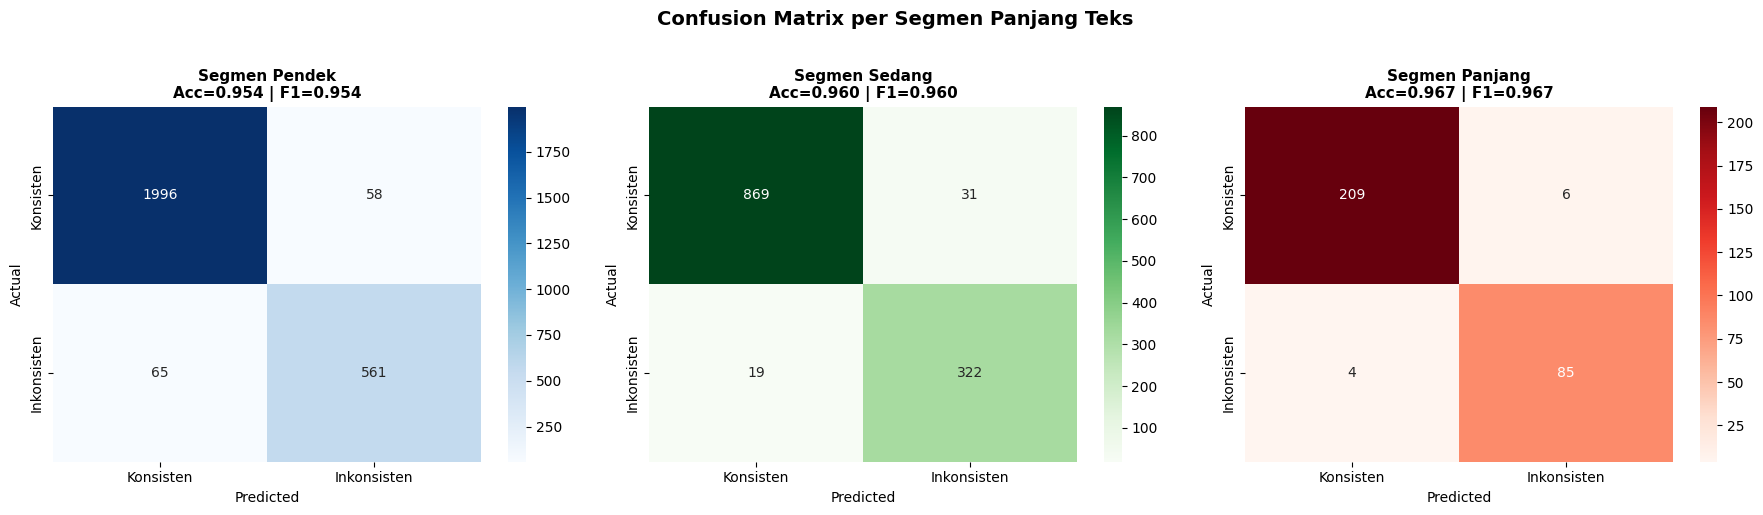

In [14]:
n_seg = len(segment_results)
fig, axes = plt.subplots(1, n_seg, figsize=(6 * n_seg, 5))
if n_seg == 1:
    axes = [axes]

seg_cmaps = {'Pendek': 'Blues', 'Sedang': 'Greens', 'Panjang': 'Reds'}

for i, seg in enumerate(SEGMENT_ORDER):
    if seg not in segment_results:
        continue
    r  = segment_results[seg]
    ax = axes[i]
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=seg_cmaps.get(seg, 'Blues'), ax=ax,
                xticklabels=['Konsisten', 'Inkonsisten'],
                yticklabels=['Konsisten', 'Inkonsisten'])
    ax.set_title(
        f'Segmen {seg}\nAcc={r["accuracy"]:.3f} | F1={r["f1_weighted"]:.3f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix per Segmen Panjang Teks', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

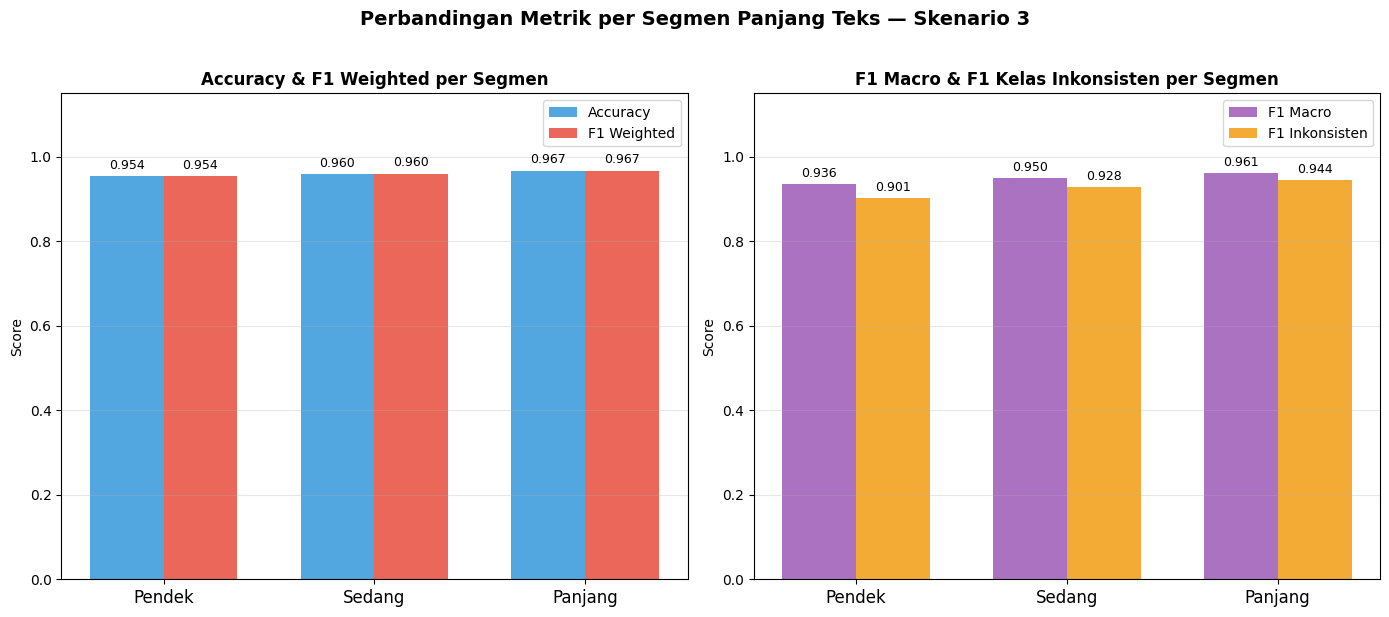

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segs     = [r['segment']          for r in segment_results.values()]
acc_vals = [r['accuracy']         for r in segment_results.values()]
f1w_vals = [r['f1_weighted']      for r in segment_results.values()]
f1m_vals = [r['f1_macro']         for r in segment_results.values()]
f1i_vals = [r['f1_inkonsisten']   for r in segment_results.values()]
x, w     = np.arange(len(segs)), 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, acc_vals, w, label='Accuracy',    color='#3498db', alpha=0.85)
b2 = ax.bar(x + w/2, f1w_vals, w, label='F1 Weighted', color='#e74c3c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(segs, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('Accuracy & F1 Weighted per Segmen', fontsize=12, fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.15); ax.grid(True, axis='y', alpha=0.3)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
b3 = ax.bar(x - w/2, f1m_vals, w, label='F1 Macro',       color='#9b59b6', alpha=0.85)
b4 = ax.bar(x + w/2, f1i_vals, w, label='F1 Inkonsisten', color='#f39c12', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(segs, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('F1 Macro & F1 Kelas Inkonsisten per Segmen', fontsize=12, fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.15); ax.grid(True, axis='y', alpha=0.3)
for bar in b3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in b4:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Perbandingan Metrik per Segmen Panjang Teks — Skenario 3', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

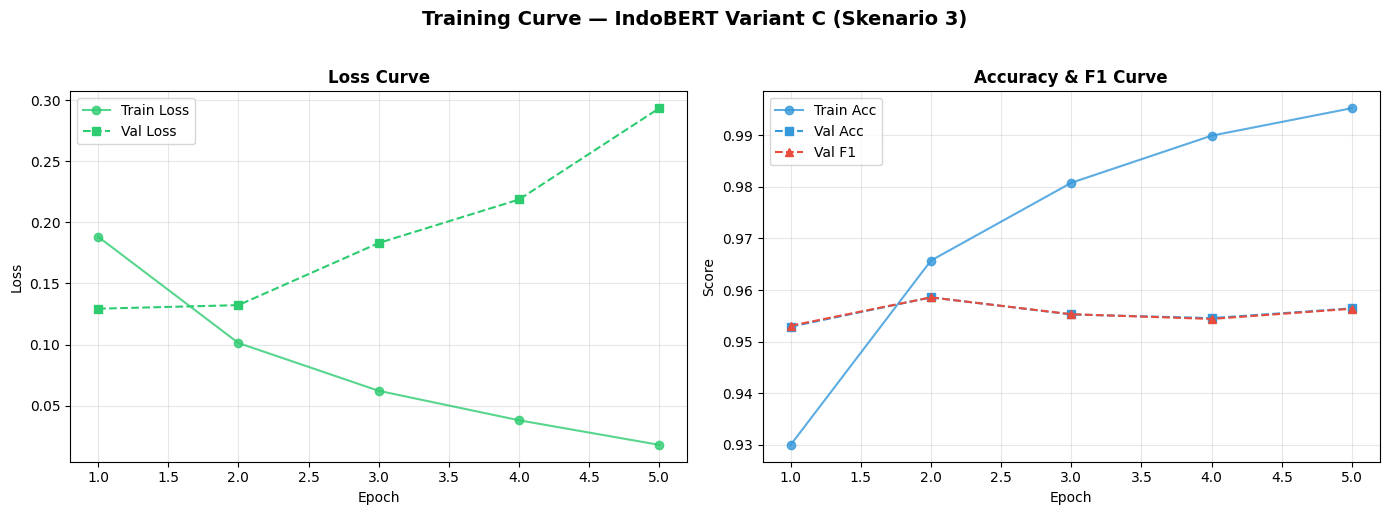

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, EPOCHS + 1)

ax = axes[0]
ax.plot(ep, history['train_loss'], '-o', label='Train Loss', color='#2ecc71', alpha=0.8)
ax.plot(ep, history['val_loss'],   '--s', label='Val Loss',   color='#2ecc71')
ax.set_title('Loss Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ep, history['train_acc'], '-o', label='Train Acc', color='#3498db', alpha=0.8)
ax.plot(ep, history['val_acc'],   '--s', label='Val Acc',   color='#3498db')
ax.plot(ep, history['val_f1'],    '--^', label='Val F1',    color='#e74c3c')
ax.set_title('Accuracy & F1 Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training Curve — IndoBERT Variant C (Skenario 3)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

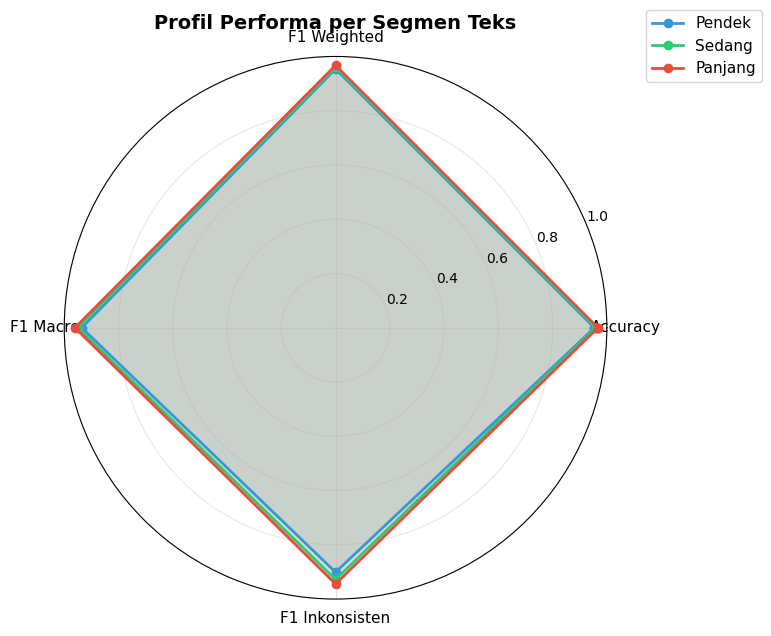

In [17]:
metrics_labels = ['Accuracy', 'F1 Weighted', 'F1 Macro', 'F1 Inkonsisten']
n_metrics = len(metrics_labels)
angles    = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles   += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = ['#3498db', '#2ecc71', '#e74c3c']

for seg, color in zip(SEGMENT_ORDER, radar_colors):
    if seg not in segment_results:
        continue
    r      = segment_results[seg]
    values = [r['accuracy'], r['f1_weighted'], r['f1_macro'], r['f1_inkonsisten']]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=seg, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Profil Performa per Segmen Teks', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Analisis Sampel Review per Segmen

In [18]:
pd.set_option('display.max_colwidth', 120)

for seg in SEGMENT_ORDER:
    if seg not in segment_results:
        continue
    r      = segment_results[seg]
    df_seg = test_df[test_df['segment'] == seg].copy().reset_index(drop=True)
    df_seg['pred']       = r['preds']
    df_seg['pred_label'] = df_seg['pred'].map({0: 'Konsisten', 1: 'Inkonsisten'})
    df_seg['true_label'] = df_seg['label'].map({0: 'Konsisten', 1: 'Inkonsisten'})

    fn = df_seg[(df_seg['label'] == 1) & (df_seg['pred'] == 0)]
    fp = df_seg[(df_seg['label'] == 0) & (df_seg['pred'] == 1)]

    print(f'\n{"="*70}')
    print(f'SEGMEN {seg.upper()} — Analisis Kesalahan Prediksi')
    print(f'{"="*70}')
    print(f'False Negative (inkonsisten diprediksi konsisten): {len(fn)}')
    print(f'False Positive (konsisten diprediksi inkonsisten): {len(fp)}')

    if len(fn) > 0:
        print(f'\nContoh False Negative (maks 3):')
        cols = ['rating', 'text', 'true_label', 'pred_label', 'word_count']
        display(fn[cols].head(3))


SEGMEN PENDEK — Analisis Kesalahan Prediksi
False Negative (inkonsisten diprediksi konsisten): 65
False Positive (konsisten diprediksi inkonsisten): 58

Contoh False Negative (maks 3):


,rating,text,true_label,pred_label,word_count
26,5,sangat membantu saya pindahan dari apk sebelah gac nyesel pkek shopee,Inkonsisten,Konsisten,11.0
36,5,lebih murah daripada maxim maxim mahal,Inkonsisten,Konsisten,6.0
63,5,"plis kakaa, jangan pakai otp whatsapp dong, aku tunggu 3 hari di email ya kaka, aku butuh banget soalnya",Inkonsisten,Konsisten,19.0



SEGMEN SEDANG — Analisis Kesalahan Prediksi
False Negative (inkonsisten diprediksi konsisten): 19
False Positive (konsisten diprediksi inkonsisten): 31

Contoh False Negative (maks 3):


,rating,text,true_label,pred_label,word_count
4,1,selama aku pakai tokopedia gak pernah dapat 0 ongkir. gak kayak si oren walupun di pelosok tetap dapat 0 ongkir,Inkonsisten,Konsisten,20.0
190,5,alhmdullilah semenjak ad gojek kmn aj enk..dan aku pun dlu satu bendera mitra gojek tpi di x go clean ..syang nya go...,Inkonsisten,Konsisten,48.0
252,5,tidak karena aplikasi ini adalah sangat penting dalam menjalankan tugas apa pun agar lebih mudah dan cepat untuk men...,Inkonsisten,Konsisten,30.0



SEGMEN PANJANG — Analisis Kesalahan Prediksi
False Negative (inkonsisten diprediksi konsisten): 4
False Positive (konsisten diprediksi inkonsisten): 6

Contoh False Negative (maks 3):


,rating,text,true_label,pred_label,word_count
31,5,aplikasi ini ssngat bagus bagiku paling number one ada tpinya kasihan yg hapenya di ram 2 seperti hape saya jika ing...,Inkonsisten,Konsisten,73.0
38,5,"kalau belanja disini saya sangat puas, tapi kendalanya adalah pada saat saya udah pesan pesanan saya. setelah 8-17 h...",Inkonsisten,Konsisten,73.0
152,5,"bagus sih, cuma kalo lagi di aplikasi lain nih kaya ig/ttk/pinterest gitu misalnya ada konten tentang shopee, nah ad...",Inkonsisten,Konsisten,51.0


In [19]:
import os

os.makedirs('models', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'model_name': MODEL_NAME,
    'max_len':    MAX_LEN,
    'best_val_f1': best_val_f1,
}, 'models/model_s3_indobert.pt')

path = 'models/model_s3_indobert.pt'
size = os.path.getsize(path) / 1e6
print('Model Skenario 3 berhasil disimpan:')
print(f'  {path}  ({size:.1f} MB)')
print(f'  Best Val F1: {best_val_f1:.4f}')


Model Skenario 3 berhasil disimpan:
  models/model_s3_indobert.pt  (498.6 MB)
  Best Val F1: 0.9586


## 10. Kesimpulan

Skenario 3 mengevaluasi pengaruh panjang teks review terhadap kemampuan model IndoBERT Variant C mendeteksi inkonsistensi sentimen-rating, dengan tiga segmen:

- **Pendek (< 20 kata):** Teks singkat dengan sinyal linguistik terbatas. Keyword inkonsistensi sulit ditangkap karena konteks minim.
- **Sedang (20-50 kata):** Teks dengan satu aspek dominan. Model mendapat cukup konteks untuk memahami polaritas sentimen.
- **Panjang (> 50 kata):** Teks multi-aspek dengan sentimen campuran. Model kesulitan menentukan polaritas dominan karena sinyal positif dan negatif hadir sekaligus.

Label inkonsistensi bersumber dari `clean_reviews.csv` yang dihasilkan oleh `preprocess.ipynb` menggunakan model pretrained `mdhugol/indonesia-bert-sentiment-classification` sebagai labeler.